# MCDI504 Machine Learning I: F4_Evaluacion - Evaluacion y Validacion del Modelo (Fase 4)

**Caso de aplicacion:** CuidateDeLaDiabete - Diabetes Prediction in India Dataset (Kaggle).  
**Integrantes:** Cristian Pasten, Enso Guidotti, Daniel Hormazabal.  
**Grupo:** 02. 

Este notebook corresponde a la Fase 4 del proyecto ABP (Evaluacion y Validacion del Modelo) y se construye directamente sobre el pipeline definido en `F3_RedesNeuronales.ipynb` (Fases 2 y 3): mismo dataset, mismo tratamiento de valores faltantes, misma particion entrenamiento/prueba (80/20 estratificada, `random_state=42`) y los mismos siete modelos de clasificacion ya entrenados (KNN, arbol de decision, SVM, Naive Bayes y MLP con una, dos y tres capas ocultas).

No se modifican los modelos ni los hiperparametros heredados de la Fase 3. Lo que agrega esta fase es:

1. Un **reporte tabulado consolidado** de accuracy, precision, recall y F1-score para los siete modelos, con matrices de confusion individuales.
2. La aplicacion de **validacion cruzada K-Fold (k=5)** al MLP de una capa oculta, exigida explicitamente por la actividad, algo que la Fase 3 no realizo (solo evaluo sobre una unica particion Hold-Out).
3. La interpretacion de la **estabilidad** de las metricas obtenidas mediante esa validacion cruzada y su relacion con el tamano del dataset y el costo computacional.

## 1. Carga de librerias

In [1]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)
from sklearn.exceptions import ConvergenceWarning

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# Paleta grafica identica a la usada en F3_RedesNeuronales.ipynb, para mantener
# coherencia visual entre las Fases 3 y 4 del informe.
GRIS_CLARO, GRIS_MEDIO, GRIS_OSCURO = '#D4D4D4', '#9A9A9A', '#4A4A4A'
ACENTO = '#B3452F'
PALETA_4 = ['#DCDCDC', '#A8A8A8', '#6E6E6E', '#3A3A3A']
CMAP_SEC = 'Greys'
plt.rcParams.update({'figure.facecolor': 'white', 'axes.titlesize': 11,
                      'axes.labelsize': 9, 'font.size': 9})

## 2. Carga de datos y preparacion (identica a la Fase 3)

Se reutiliza el dataset `diabetes_prediction_india.csv` (5.292 fichas de pacientes, 27 variables), la variable objetivo `Diabetes_Status`, y el mismo tratamiento de valores faltantes documentado desde la Fase 1: `Alcohol_Intake` (33,6% de valores faltantes) se recodifica con la categoria explicita `'No_Registrado'`, y `Polycystic_Ovary_Syndrome` recodifica `'0'` (no aplica biologicamente) como `'No_Aplica'`.

In [2]:
df = pd.read_csv('../data/diabetes_prediction_india.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

df_proc = df.copy()
df_proc['Alcohol_Intake'] = df_proc['Alcohol_Intake'].fillna('No_Registrado')
df_proc['Polycystic_Ovary_Syndrome'] = df_proc['Polycystic_Ovary_Syndrome'].replace('0', 'No_Aplica')
df_proc['Diabetes_Status'] = df_proc['Diabetes_Status'].map({'Yes': 1, 'No': 0})

cat_cols = [c for c in df_proc.select_dtypes(include=['object', 'string']).columns if c != 'Diabetes_Status']
num_cols = [c for c in df_proc.select_dtypes(include='number').columns if c != 'Diabetes_Status']

df_encoded = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['Diabetes_Status'])
y = df_encoded['Diabetes_Status']
print("X:", X.shape, " y:", y.shape)
print("Balance de clases:", y.value_counts(normalize=True).round(4).to_dict())

Dimensiones del dataset: 5292 filas x 27 columnas
X: (5292, 33)  y: (5292,)
Balance de clases: {1: 0.511, 0: 0.489}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Balance clase en train:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Balance clase en test:", y_test.value_counts(normalize=True).round(4).to_dict())

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train: (4233, 33)  X_test: (1059, 33)
Balance clase en train: {1: 0.511, 0: 0.489}
Balance clase en test: {1: 0.5109, 0: 0.4891}


**Conjunto de prueba utilizado:** 1.059 observaciones (20% del dataset), separadas mediante `train_test_split(test_size=0.20, random_state=42, stratify=y)`. El balance de clases se mantiene casi identico entre entrenamiento (51,1%/48,9%) y prueba (51,1%/48,9%), heredado de la Fase 3.

**Modelos considerados en la evaluacion:** KNN (`n_neighbors=5`), arbol de decision (`max_depth=5`), SVM (`kernel='rbf'`, `C=1`), Naive Bayes (`GaussianNB`) y tres arquitecturas de red neuronal MLP (una, dos y tres capas ocultas), todos con `random_state=42`. El modelo de referencia para la validacion cruzada de esta fase es el **MLP de una capa oculta** (`hidden_layer_sizes=(100,)`), segun lo exige la actividad.

**Justificacion del uso de metricas de clasificacion:** el problema es de clasificacion binaria (`Diabetes_Status`: Yes/No), con clase objetivo *Yes* (recodificada a 1) como clase positiva. La matriz de confusion permite distinguir verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos; a partir de ella se derivan accuracy (aciertos globales), precision (confiabilidad de las predicciones positivas), recall (capacidad de deteccion de la clase positiva) y F1-score (equilibrio entre precision y recall). El balance casi ideal de clases (51,1%/48,9%) permite que el accuracy sea informativo, pero se complementa con las demas metricas para no ocultar comportamientos distintos entre clases.

## 3. Evaluacion de los modelos supervisados (herencia de la Fase 3)

Se reentrenan los siete modelos exactamente con los mismos hiperparametros de `F3_RedesNeuronales.ipynb`, para generar la matriz de confusion y las metricas de cada uno sobre el conjunto de prueba dentro de este mismo notebook (trazabilidad completa del pipeline de evaluacion).

In [4]:
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always', ConvergenceWarning)
        modelo.fit(X_tr, y_tr)
        convergio = not any(issubclass(x.category, ConvergenceWarning) for x in w)
    y_pred = modelo.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    espec = tn / (tn + fp)
    resultado = {
        'Modelo': nombre, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-score': f1, 'Especificidad': espec, 'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp)
    }
    if type(modelo).__name__ == 'MLPClassifier':
        estado = 'Si' if convergio else 'No (alcanzo max_iter)'
        print(f"  Iteraciones utilizadas: {modelo.n_iter_} / max_iter={modelo.max_iter} | Convergencia: {estado}")
    return resultado, cm, modelo

def graficar_matriz(cm, titulo, archivo, figsize=(4.6, 3.8)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_SEC,
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['Real No', 'Real Yes'], ax=ax)
    ax.set_title(titulo, fontsize=10, wrap=True)
    ax.set_ylabel('Etiqueta verdadera')
    ax.set_xlabel('Etiqueta predicha')
    plt.tight_layout()
    plt.savefig(archivo, dpi=150)
    plt.show()

resultados = []
matrices = {}

Accuracy KNN: 0.4948


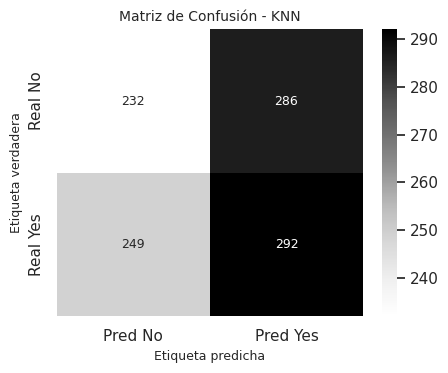

In [5]:
res, cm, _ = evaluar_modelo('KNN', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
                             X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['KNN'] = cm
print(f"Accuracy KNN: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - KNN', '../figures/f4_fig1_cm_knn.png')

Accuracy Árbol de Decisión: 0.5033


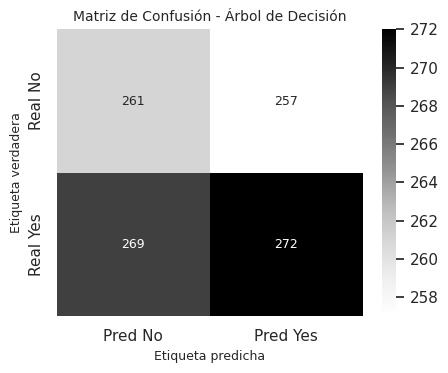

In [6]:
res, cm, _ = evaluar_modelo('Árbol de Decisión', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5, criterion='gini'),
                             X_train, X_test, y_train, y_test)
resultados.append(res); matrices['Árbol'] = cm
print(f"Accuracy Árbol de Decisión: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - Árbol de Decisión', '../figures/f4_fig2_cm_arbol.png')

Accuracy SVM: 0.5052


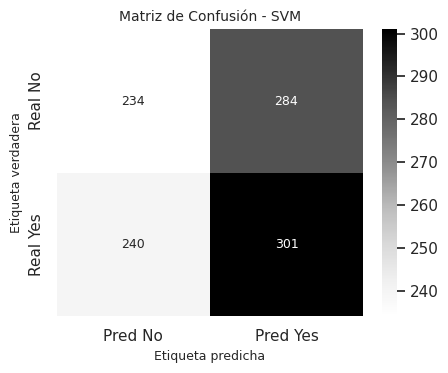

In [7]:
res, cm, _ = evaluar_modelo('SVM', SVC(kernel='rbf', C=1, random_state=RANDOM_STATE),
                             X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['SVM'] = cm
print(f"Accuracy SVM: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - SVM', '../figures/f4_fig3_cm_svm.png')

Accuracy Naive Bayes: 0.5033


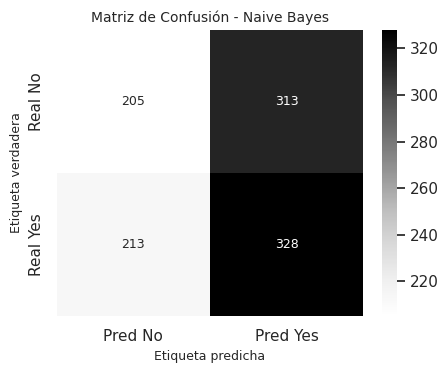

In [8]:
res, cm, _ = evaluar_modelo('Naive Bayes', GaussianNB(),
                             X_train, X_test, y_train, y_test)
resultados.append(res); matrices['NB'] = cm
print(f"Accuracy Naive Bayes: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - Naive Bayes', '../figures/f4_fig4_cm_nb.png')

  Iteraciones utilizadas: 500 / max_iter=500 | Convergencia: No (alcanzo max_iter)
Accuracy MLP (1 capa oculta): 0.5080


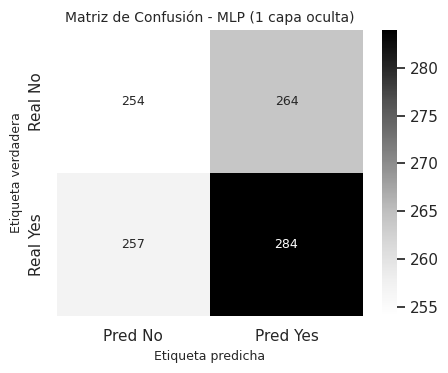

In [9]:
mlp_1 = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                       max_iter=500, random_state=RANDOM_STATE)
res, cm, mlp_1 = evaluar_modelo('MLP 1 capa oculta', mlp_1, X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['MLP1'] = cm
print(f"Accuracy MLP (1 capa oculta): {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - MLP (1 capa oculta)', '../figures/f4_fig5_cm_mlp1.png')

  Iteraciones utilizadas: 338 / max_iter=500 | Convergencia: Si
Accuracy MLP (2 capas ocultas): 0.4967


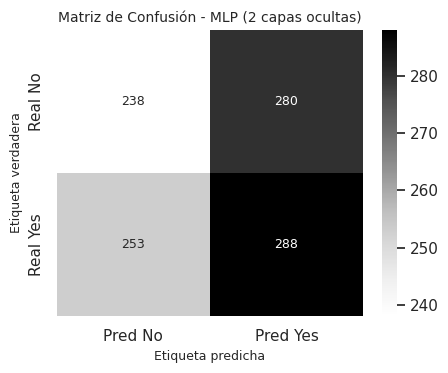

In [10]:
mlp_2 = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
                       max_iter=500, random_state=RANDOM_STATE)
res, cm, mlp_2 = evaluar_modelo('MLP 2 capas ocultas', mlp_2, X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['MLP2'] = cm
print(f"Accuracy MLP (2 capas ocultas): {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - MLP (2 capas ocultas)', '../figures/f4_fig6_cm_mlp2.png')

  Iteraciones utilizadas: 161 / max_iter=500 | Convergencia: Si
Accuracy MLP (3 capas ocultas): 0.4693


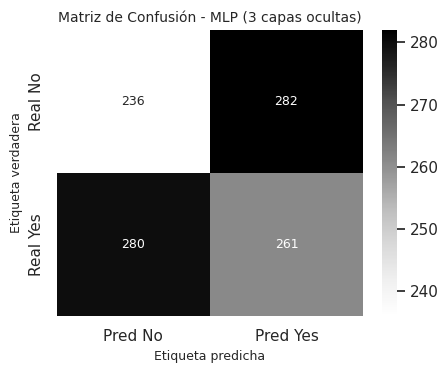

In [11]:
mlp_3 = MLPClassifier(hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam',
                       max_iter=500, random_state=RANDOM_STATE)
res, cm, mlp_3 = evaluar_modelo('MLP 3 capas ocultas', mlp_3, X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['MLP3'] = cm
print(f"Accuracy MLP (3 capas ocultas): {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - MLP (3 capas ocultas)', '../figures/f4_fig7_cm_mlp3.png')

## 4. Reporte tabulado consolidado de metricas

Se consolidan accuracy, precision, recall, F1-score y especificidad de los siete modelos en una unica tabla, sobre el mismo conjunto de prueba (n=1.059).

In [12]:
df_resultados = pd.DataFrame(resultados)
cols = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Especificidad', 'TN', 'FP', 'FN', 'TP']
df_resultados = df_resultados[cols].sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,Especificidad,TN,FP,FN,TP
0,MLP 1 capa oculta,0.5080,0.5182,0.5250,0.5216,0.4903,254,264,257,284
1,SVM,0.5052,0.5145,0.5564,0.5346,0.4517,234,284,240,301
2,Árbol de Decisión,0.5033,0.5142,0.5028,0.5084,0.5039,261,257,269,272
3,Naive Bayes,0.5033,0.5117,0.6063,0.5550,0.3958,205,313,213,328
4,MLP 2 capas ocultas,0.4967,0.5070,0.5323,0.5194,0.4595,238,280,253,288
5,KNN,0.4948,0.5052,0.5397,0.5219,0.4479,232,286,249,292
6,MLP 3 capas ocultas,0.4693,0.4807,0.4824,0.4815,0.4556,236,282,280,261


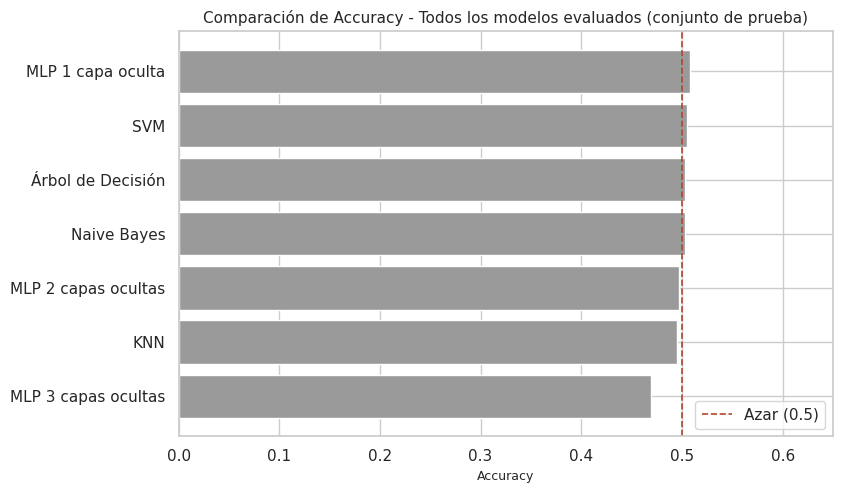

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5))
orden = df_resultados.sort_values('Accuracy')
ax.barh(orden['Modelo'], orden['Accuracy'], color=GRIS_MEDIO)
ax.axvline(0.5, color=ACENTO, linestyle='--', linewidth=1.2, label='Azar (0.5)')
ax.set_xlabel('Accuracy')
ax.set_title('Comparación de Accuracy - Todos los modelos evaluados (conjunto de prueba)')
ax.set_xlim(0, 0.65)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../figures/f4_fig8_comparacion_accuracy.png', dpi=150)
plt.show()

**Interpretacion inicial:** los siete modelos obtienen accuracy en un rango estrecho (0,4693 a 0,5080), todos cercanos al 50% esperado por azar en un problema binario balanceado (51,1%/48,9%). El MLP de una capa oculta obtiene el mayor accuracy puntual (0,5080), seguido por SVM (0,5052) y, empatados, el arbol de decision y Naive Bayes (0,5033). Ningun modelo, independientemente de su naturaleza (basado en distancia, en reglas, en margenes, probabilistico o conexionista), se aleja de forma sustantiva del desempeno esperado por azar, hallazgo consistente con la ausencia de correlacion lineal (Fase 1) y no lineal (Fase 3) entre las variables clinicas disponibles y `Diabetes_Status`.

La clase objetivo (positiva) es **Diabetes_Status = Yes (1)**. La eleccion de accuracy, precision, recall y F1-score como conjunto de metricas es pertinente porque el problema es de clasificacion binaria con clases casi balanceadas, lo que hace que el accuracy sea razonablemente informativo, mientras que precision y recall permiten verificar que ningun modelo compense un accuracy bajo mediante un sesgo sistematico hacia una clase.

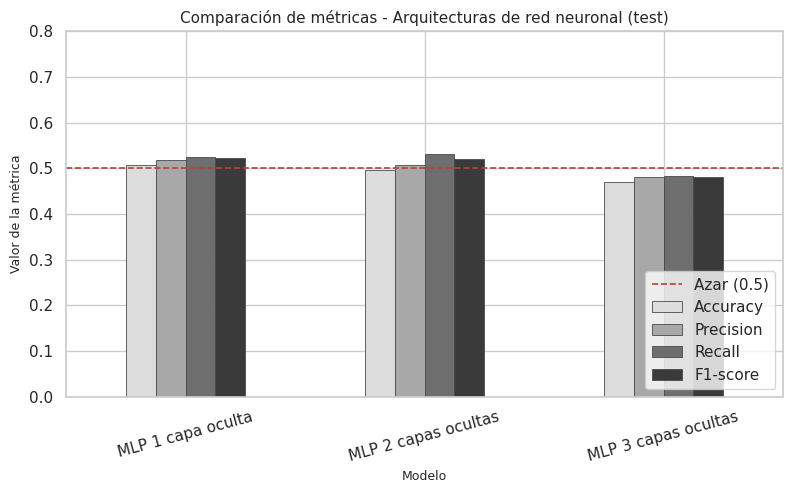

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
df_mlp_plot = df_resultados[df_resultados['Modelo'].str.contains('MLP')].set_index('Modelo')
df_mlp_plot[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', ax=ax, color=PALETA_4, edgecolor=GRIS_OSCURO, linewidth=0.6)
ax.axhline(0.5, color=ACENTO, linestyle='--', linewidth=1.2, label='Azar (0.5)')
ax.set_title('Comparación de métricas - Arquitecturas de red neuronal (test)')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 0.8)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/f4_fig9_metricas_mlp.png', dpi=150)
plt.show()

## 5. Matriz de confusión y métricas de clasificación por modelo

Se detalla, para cada modelo, la matriz de confusión (filas = clase real, columnas = clase predicha; clase positiva = *Diabetes_Status = Yes*) y las métricas asociadas.

In [15]:
for _, fila in df_resultados.iterrows():
    print(f"--- {fila['Modelo']} ---")
    print(f"  Accuracy={fila['Accuracy']:.4f}  Precision={fila['Precision']:.4f}  "
          f"Recall={fila['Recall']:.4f}  F1-score={fila['F1-score']:.4f}  "
          f"Especificidad={fila['Especificidad']:.4f}")
    print(f"  TN={int(fila['TN'])}  FP={int(fila['FP'])}  FN={int(fila['FN'])}  TP={int(fila['TP'])}\n")

--- MLP 1 capa oculta ---
  Accuracy=0.5080  Precision=0.5182  Recall=0.5250  F1-score=0.5216  Especificidad=0.4903
  TN=254  FP=264  FN=257  TP=284

--- SVM ---
  Accuracy=0.5052  Precision=0.5145  Recall=0.5564  F1-score=0.5346  Especificidad=0.4517
  TN=234  FP=284  FN=240  TP=301

--- Árbol de Decisión ---
  Accuracy=0.5033  Precision=0.5142  Recall=0.5028  F1-score=0.5084  Especificidad=0.5039
  TN=261  FP=257  FN=269  TP=272

--- Naive Bayes ---
  Accuracy=0.5033  Precision=0.5117  Recall=0.6063  F1-score=0.5550  Especificidad=0.3958
  TN=205  FP=313  FN=213  TP=328

--- MLP 2 capas ocultas ---
  Accuracy=0.4967  Precision=0.5070  Recall=0.5323  F1-score=0.5194  Especificidad=0.4595
  TN=238  FP=280  FN=253  TP=288

--- KNN ---
  Accuracy=0.4948  Precision=0.5052  Recall=0.5397  F1-score=0.5219  Especificidad=0.4479
  TN=232  FP=286  FN=249  TP=292

--- MLP 3 capas ocultas ---
  Accuracy=0.4693  Precision=0.4807  Recall=0.4824  F1-score=0.4815  Especificidad=0.4556
  TN=236  FP=2

**Interpretación de cada métrica en el caso:**
- **Accuracy** = (VP+VN)/Total: proporción global de pacientes correctamente clasificados. Dado el balance casi ideal de clases, es una métrica razonablemente informativa, aunque insuficiente por sí sola.
- **Precisión** = VP/(VP+FP): de los pacientes que el modelo predice como diabéticos, qué proporción realmente lo es. Relevante para evitar sobrecargar el sistema de salud con falsas alarmas.
- **Recall** = VP/(VP+FN): de los pacientes realmente diabéticos, qué proporción detecta el modelo. Crítico en un contexto de tamizaje temprano, donde omitir un caso real (falso negativo) tiene mayor costo clínico que una falsa alarma.
- **F1-score**: media armónica entre precisión y recall; resume el equilibrio entre ambas cuando ninguna domina claramente sobre la otra.

Con accuracy entre 0,4693 y 0,5080, ningún modelo logra un desempeño clínicamente útil sobre ninguna de estas métricas.

## 5.1 Linea base e intervalos de confianza del accuracy

Para dimensionar si el desempeno observado supera una referencia trivial, se calcula la **linea base del clasificador mayoritario** (`DummyClassifier(strategy='most_frequent')`), que predice siempre la clase mas frecuente, y el **intervalo de confianza al 95%** del accuracy de cada modelo sobre el conjunto de prueba. El intervalo se construye con la aproximacion normal (Wald) para una proporcion: acc +/- 1,96 * raiz(acc*(1-acc)/n), con n=1.059.


In [16]:
# Linea base (clasificador mayoritario) e intervalos de confianza al 95% del accuracy.
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
acc_base = accuracy_score(y_test, dummy.predict(X_test))
n_test = len(y_test)

filas_ic = []
for _, fila in df_resultados.iterrows():
    acc = fila['Accuracy']
    se = np.sqrt(acc * (1 - acc) / n_test)      # error estandar de una proporcion
    li, ls = acc - 1.96 * se, acc + 1.96 * se   # intervalo de Wald al 95%
    filas_ic.append({'Modelo': fila['Modelo'], 'Accuracy': acc, 'Error_estandar': se,
                     'IC95_inferior': li, 'IC95_superior': ls,
                     'Contiene_linea_base': bool(li <= acc_base <= ls)})

df_ic = pd.DataFrame(filas_ic)
print(f"Linea base (clasificador mayoritario) en el conjunto de prueba: {acc_base:.4f} (n={n_test})")
df_ic.round(4)


Linea base (clasificador mayoritario) en el conjunto de prueba: 0.5109 (n=1059)


,Modelo,Accuracy,Error_estandar,IC95_inferior,IC95_superior,Contiene_linea_base
0,MLP 1 capa oculta,0.5080,0.0154,0.4779,0.5381,True
1,SVM,0.5052,0.0154,0.4751,0.5353,True
2,Árbol de Decisión,0.5033,0.0154,0.4732,0.5334,True
3,Naive Bayes,0.5033,0.0154,0.4732,0.5334,True
4,MLP 2 capas ocultas,0.4967,0.0154,0.4666,0.5268,True
5,KNN,0.4948,0.0154,0.4647,0.5249,True
6,MLP 3 capas ocultas,0.4693,0.0153,0.4393,0.4994,False


**Lectura:** la linea base del clasificador mayoritario en el conjunto de prueba es 0,5109. Seis de los siete modelos tienen un intervalo de confianza al 95% del accuracy que **contiene** ese valor, es decir, su desempeno no se distingue estadisticamente de predecir siempre la clase mayoritaria. La unica excepcion es el **MLP de tres capas ocultas**, cuyo intervalo ([0,4393; 0,4994]) queda completamente **por debajo** de la linea base: ese modelo es significativamente peor que la referencia trivial. El MLP de una capa oculta, modelo de referencia de esta fase, tiene un intervalo de [0,4779; 0,5381], que contiene tanto la linea base como el nivel de azar (0,50).


## 6. Validación cruzada de red neuronal con una capa oculta (K-Fold, k=5)

La actividad exige aplicar una técnica de validación cruzada al MLP de una capa oculta, algo que la Fase 3 no realizó (solo evaluó sobre una única partición Hold-Out). Se aplica **K-Fold Cross-Validation con k=5**, `shuffle=True` y `random_state=42`, sobre el conjunto de entrenamiento escalado (`X_train_scaled`, 4.233 observaciones). El modelo evaluado mantiene exactamente los mismos hiperparámetros del MLP de una capa oculta de la Fase 3 (`hidden_layer_sizes=(100,)`, `activation='relu'`, `solver='adam'`, `max_iter=500`).

**Técnica seleccionada y justificación:** K-Fold divide el conjunto de entrenamiento en cinco particiones; en cada iteración, cuatro se usan para entrenar y una para validar, rotando la partición de validación. Frente a Hold-Out (una sola partición, ya usada para el conjunto de prueba), K-Fold entrega una estimación de desempeño basada en cinco evaluaciones independientes, reduciendo la dependencia de una muestra particular. Frente a Leave-One-Out (una partición por cada observación, 4.233 entrenamientos para este conjunto), K-Fold con k=5 ofrece un costo computacional considerablemente menor mientras preserva una estimación razonablemente estable, lo que resulta apropiado para un modelo de red neuronal, cuyo entrenamiento es más costoso que el de un modelo tradicional.

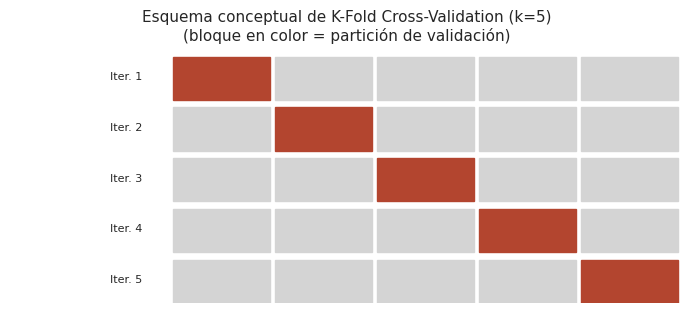

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.2))
k = 5
for fold in range(k):
    for block in range(k):
        color = ACENTO if block == fold else GRIS_CLARO
        ax.add_patch(plt.Rectangle((block, k - fold - 1), 0.95, 0.85, color=color))
    ax.text(-0.3, k - fold - 0.55, f'Iter. {fold+1}', ha='right', va='center', fontsize=8)
ax.set_xlim(-1.6, k)
ax.set_ylim(0, k)
ax.axis('off')
ax.set_title('Esquema conceptual de K-Fold Cross-Validation (k=5)\n(bloque en color = partición de validación)')
plt.tight_layout()
plt.savefig('../figures/f4_fig12_esquema_kfold.png', dpi=150)
plt.show()

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mlp_cv_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                              max_iter=500, random_state=RANDOM_STATE)

fold_rows = []
conf_matrix_cv_agg = np.zeros((2, 2), dtype=int)

X_train_scaled_arr = X_train_scaled.to_numpy()
y_train_arr = y_train.to_numpy()

for i, (train_index, val_index) in enumerate(kf.split(X_train_scaled_arr), start=1):
    X_tr_fold, X_val_fold = X_train_scaled_arr[train_index], X_train_scaled_arr[val_index]
    y_tr_fold, y_val_fold = y_train_arr[train_index], y_train_arr[val_index]

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always', ConvergenceWarning)
        mlp_cv_model.fit(X_tr_fold, y_tr_fold)
        convergio_fold = not any(issubclass(x.category, ConvergenceWarning) for x in w)

    y_pred_val = mlp_cv_model.predict(X_val_fold)
    acc_f = accuracy_score(y_val_fold, y_pred_val)
    prec_f = precision_score(y_val_fold, y_pred_val)
    rec_f = recall_score(y_val_fold, y_pred_val)
    f1_f = f1_score(y_val_fold, y_pred_val)
    cm_f = confusion_matrix(y_val_fold, y_pred_val)
    conf_matrix_cv_agg += cm_f

    fold_rows.append({'Fold': i, 'Accuracy': acc_f, 'Precision': prec_f, 'Recall': rec_f,
                       'F1-score': f1_f, 'Iteraciones': mlp_cv_model.n_iter_,
                       'Convergencia': 'Si' if convergio_fold else 'No (alcanzo max_iter)'})
    print(f"Fold {i}: acc={acc_f:.4f} prec={prec_f:.4f} rec={rec_f:.4f} f1={f1_f:.4f} "
          f"iter={mlp_cv_model.n_iter_} conv={'Si' if convergio_fold else 'No'}")

df_folds = pd.DataFrame(fold_rows)
df_folds.round(4)

Fold 1: acc=0.5089 prec=0.5448 rec=0.5329 f1=0.5388 iter=500 conv=No


Fold 2: acc=0.4947 prec=0.4768 rec=0.5567 f1=0.5136 iter=500 conv=No


Fold 3: acc=0.4935 prec=0.4957 rec=0.5412 f1=0.5174 iter=500 conv=No


Fold 4: acc=0.4941 prec=0.5034 rec=0.5220 f1=0.5125 iter=500 conv=No


Fold 5: acc=0.5024 prec=0.5278 rec=0.5124 f1=0.5200 iter=500 conv=No


,Fold,Accuracy,Precision,Recall,F1-score,Iteraciones,Convergencia
0,1,0.5089,0.5448,0.5329,0.5388,500,No (alcanzo max_iter)
1,2,0.4947,0.4768,0.5567,0.5136,500,No (alcanzo max_iter)
2,3,0.4935,0.4957,0.5412,0.5174,500,No (alcanzo max_iter)
3,4,0.4941,0.5034,0.5220,0.5125,500,No (alcanzo max_iter)
4,5,0.5024,0.5278,0.5124,0.5200,500,No (alcanzo max_iter)


In [19]:
resumen_cv = pd.DataFrame([{
    'Accuracy_media': df_folds['Accuracy'].mean(), 'Accuracy_std': df_folds['Accuracy'].std(ddof=1),
    'Precision_media': df_folds['Precision'].mean(), 'Precision_std': df_folds['Precision'].std(ddof=1),
    'Recall_media': df_folds['Recall'].mean(), 'Recall_std': df_folds['Recall'].std(ddof=1),
    'F1_media': df_folds['F1-score'].mean(), 'F1_std': df_folds['F1-score'].std(ddof=1),
}])
print("Resumen validación cruzada K-Fold (k=5) - MLP 1 capa oculta:")
resumen_cv.round(4)

Resumen validación cruzada K-Fold (k=5) - MLP 1 capa oculta:


,Accuracy_media,Accuracy_std,Precision_media,Precision_std,Recall_media,Recall_std,F1_media,F1_std
0,0.4987,0.0067,0.5097,0.0268,0.533,0.0171,0.5205,0.0107


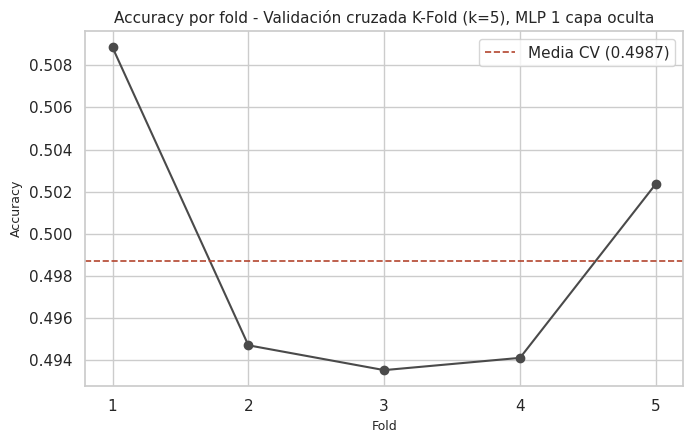

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_folds['Fold'], df_folds['Accuracy'], marker='o', color=GRIS_OSCURO, linewidth=1.5)
media_cv = df_folds['Accuracy'].mean()
ax.axhline(media_cv, color=ACENTO, linestyle='--', linewidth=1.2, label=f'Media CV ({media_cv:.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy por fold - Validación cruzada K-Fold (k=5), MLP 1 capa oculta')
ax.set_xticks(df_folds['Fold'])
ax.legend()
plt.tight_layout()
plt.savefig('../figures/f4_fig10_accuracy_fold.png', dpi=150)
plt.show()

Matriz de confusión agregada (suma de los 5 folds):
[[ 959 1111]
 [1011 1152]]

Especificidad agregada CV: 0.4633


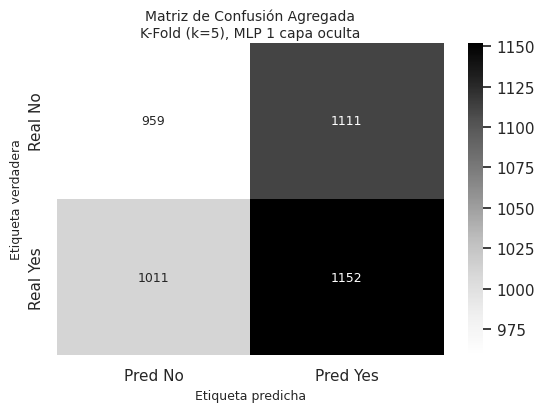

In [21]:
tn_cv, fp_cv, fn_cv, tp_cv = conf_matrix_cv_agg.ravel()
espec_cv = tn_cv / (tn_cv + fp_cv)

print("Matriz de confusión agregada (suma de los 5 folds):")
print(conf_matrix_cv_agg)
print(f"\nEspecificidad agregada CV: {espec_cv:.4f}")

graficar_matriz(conf_matrix_cv_agg,
                 'Matriz de Confusión Agregada\nK-Fold (k=5), MLP 1 capa oculta',
                 '../figures/f4_fig11_cm_agregada_cv.png',
                 figsize=(5.6, 4.2))

**Interpretación de la estabilidad observada:** el accuracy promedio de la validación cruzada (0,4987) es prácticamente idéntico al azar teórico (0,50) y a la línea base del clasificador mayoritario, con una desviación estándar muy baja (0,0067). Esta baja variabilidad entre folds indica que el modelo es **estable**, en el sentido de que su desempeño no fluctúa de forma relevante entre distintas particiones de entrenamiento/validación; sin embargo, esa estabilidad se produce en torno al nivel de azar, no en torno a un buen desempeño. En otras palabras: el MLP de una capa oculta es un modelo confiablemente mediocre sobre este dataset, y la validación cruzada permite afirmar esto con mayor solidez metodológica que una única partición Hold-Out, porque descarta que el resultado observado en el conjunto de prueba (accuracy=0,5080) haya sido un artefacto favorable de esa partición particular; de hecho, el intervalo de confianza al 95% del accuracy en el conjunto de prueba ([0,4779; 0,5381]) contiene también el valor medio obtenido en la validación cruzada.

**Relación entre tamaño del dataset, costo computacional y estabilidad esperada:** con 4.233 observaciones de entrenamiento, K-Fold con k=5 entrena el MLP cinco veces sobre particiones de aproximadamente 3.386 observaciones cada una, un costo computacional moderado y perfectamente asumible. Leave-One-Out exigiría 4.233 entrenamientos, un costo desproporcionado para el beneficio esperado, especialmente considerando que la baja desviación estándar observada con k=5 ya demuestra que la estimación es estable sin necesidad de maximizar el número de particiones. Hold-Out, en cambio, entrega una única estimación (accuracy=0,5080 en el conjunto de prueba) sin evidencia directa de su variabilidad; K-Fold permite cuantificar esa variabilidad explícitamente (std=0,0067).

In [22]:
with open('../scripts/f4_resultados_notebook.json', 'w', encoding='utf-8') as f:
    json.dump({
        'resultados_modelos': df_resultados.round(4).to_dict(orient='records'),
        'cv_folds': df_folds.round(4).to_dict(orient='records'),
        'cv_resumen': resumen_cv.round(4).to_dict(orient='records')[0],
        'cv_matriz_agregada': conf_matrix_cv_agg.tolist(),
        'cv_especificidad_agregada': round(float(espec_cv), 4),
        'linea_base_test': round(float(acc_base), 4),
        'ic95_accuracy_modelos': df_ic.round(4).to_dict(orient='records'),
    }, f, indent=2, ensure_ascii=False)
print("Resultados de la Fase 4 guardados.")

Resultados de la Fase 4 guardados.


## 7. Comparación entre desempeño puntual y desempeño validado

Se compara el desempeño observado en el conjunto de prueba (Hold-Out, sección 4) con el desempeño validado mediante K-Fold (sección 6), para el MLP de una capa oculta.

In [23]:
comparacion_final = pd.DataFrame([
    {'Evaluación': 'Hold-Out (conjunto de prueba, n=1.059)',
     'Accuracy': df_resultados.loc[df_resultados['Modelo']=='MLP 1 capa oculta', 'Accuracy'].iloc[0],
     'Precision': df_resultados.loc[df_resultados['Modelo']=='MLP 1 capa oculta', 'Precision'].iloc[0],
     'Recall': df_resultados.loc[df_resultados['Modelo']=='MLP 1 capa oculta', 'Recall'].iloc[0],
     'F1-score': df_resultados.loc[df_resultados['Modelo']=='MLP 1 capa oculta', 'F1-score'].iloc[0],
     'Desv. estándar': None},
    {'Evaluación': 'K-Fold CV (k=5, conjunto de entrenamiento, n=4.233)',
     'Accuracy': df_folds['Accuracy'].mean(), 'Precision': df_folds['Precision'].mean(),
     'Recall': df_folds['Recall'].mean(), 'F1-score': df_folds['F1-score'].mean(),
     'Desv. estándar (accuracy)': df_folds['Accuracy'].std(ddof=1)},
])
comparacion_final.round(4)

,Evaluación,Accuracy,Precision,Recall,F1-score,Desv. estándar,Desv. estándar (accuracy)
0,"Hold-Out (conjunto de prueba, n=1.059)",0.5080,0.5182,0.525,0.5216,NaN,NaN
1,"K-Fold CV (k=5, conjunto de entrenamiento, n=4...",0.4987,0.5097,0.533,0.5205,NaN,0.0067


**Lectura conjunta:** el accuracy validado por K-Fold (0,4987) es levemente inferior al accuracy puntual en el conjunto de prueba (0,5080), diferencia esperable porque la validación cruzada estima generalización sobre múltiples particiones y no sobre una única muestra. La diferencia (0,0093) es pequeña frente a la desviación estándar entre folds (0,0067) y frente al margen de error del conjunto de prueba (±0,03 aproximadamente, según el IC95), por lo que ambas estimaciones son estadísticamente compatibles: no hay evidencia de que el resultado en el conjunto de prueba haya sido optimista respecto del desempeño real del modelo.

## 8. Conclusiones de la Fase 4

- Los siete modelos evaluados (cuatro tradicionales y tres redes MLP) obtienen accuracy entre 0,4693 y 0,5080 sobre el conjunto de prueba, en línea con el hallazgo de ausencia de señal explotable documentado desde la Fase 1 (sin correlación de Pearson significativa) y confirmado en la Fase 3 (sin capacidad predictiva no lineal).
- El MLP de una capa oculta, sometido a validación cruzada K-Fold (k=5) según lo exige esta fase, muestra una estabilidad alta (std=0,0067) pero en torno al nivel de azar (media=0,4987), no en torno a un buen desempeño.
- La validación cruzada aporta evidencia metodológica adicional, no disponible en la Fase 3, de que el resultado puntual del conjunto de prueba no fue un artefacto favorable de esa partición: el intervalo de confianza del accuracy en prueba y la media de la validación cruzada son consistentes entre sí.
- Considerando desempeño, estabilidad, fortalezas, limitaciones e implicancias analíticas, ningún modelo, incluido el MLP de una capa oculta validado por K-Fold, constituye una base suficiente para un modelo predictivo clínicamente útil sobre este dataset en su estado actual. La recomendación, heredada y reforzada desde las Fases 1 a 3, es verificar el origen y la calidad del dataset o incorporar datos clínicos reales antes de avanzar hacia una fase de despliegue.